# GeoBench So2Sat

## Intro

So2Sat is a dataset designed for multimodal classification. Introduced by [Zhu et al. 2019](https://arxiv.org/pdf/1912.12171), the aim is to classify of local Climate Zones.

## Dataset Characteristics

- **Modalities**: 
  - Sentinel-1 SAR (VV, VH polarizations)
  - Sentinel-2 Optical (10 spectral bands)
- **Spatial Resolution**: 10m ground sample distance
- **Spectral Bands**: 
  - S2: 10 bands (B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12)
  - S1: 2 polarizations (VV, VH)
- **Image Dimensions**: 32x32 pixels (0.32km x 0.32km chips)
- **Geographic Distribution**: Global. However, the dataset was released without geospatial information.

## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

1. **Split Generation**:
   - Used the splits from GEO-Bench v1


## References

1. Zhu, Xiao Xiang, et al. "So2Sat LCZ42: A benchmark dataset for global local climate zones classification." arXiv preprint arXiv:1912.12171 (2019).

2. Lacoste, A., Lehmann, N., Rodriguez, P., Sherwin, E., Kerner, H., Lütjens, B., ... & Zhu, X. (2023). Geo-bench: Toward foundation models for earth monitoring. Advances in Neural Information Processing Systems, 36, 51080-51093.

In [3]:
import warnings
from pathlib import Path

import torch

from geobench_v2.datamodules import GeoBenchSo2SatDataModule

warnings.filterwarnings("ignore")

In [6]:
PROJECT_ROOT = Path("../../")

datamodule = GeoBenchSo2SatDataModule(
    img_size=64,
    batch_size=16,
    num_workers=4,
    root=PROJECT_ROOT / "data" / "so2sat",
    data_normalizer=torch.nn.Identity(),  # we do custom normalization in the tutorial
)
datamodule.setup("fit")
datamodule.setup("test")

print("So2Sat datamodule initialized successfully!")
print(f"Training samples: {len(datamodule.train_dataset)}")
print(f"Validation samples: {len(datamodule.val_dataset)}")
print(f"Test samples: {len(datamodule.test_dataset)}")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity
So2Sat datamodule initialized successfully!
Training samples: 19992
Validation samples: 986
Test samples: 986


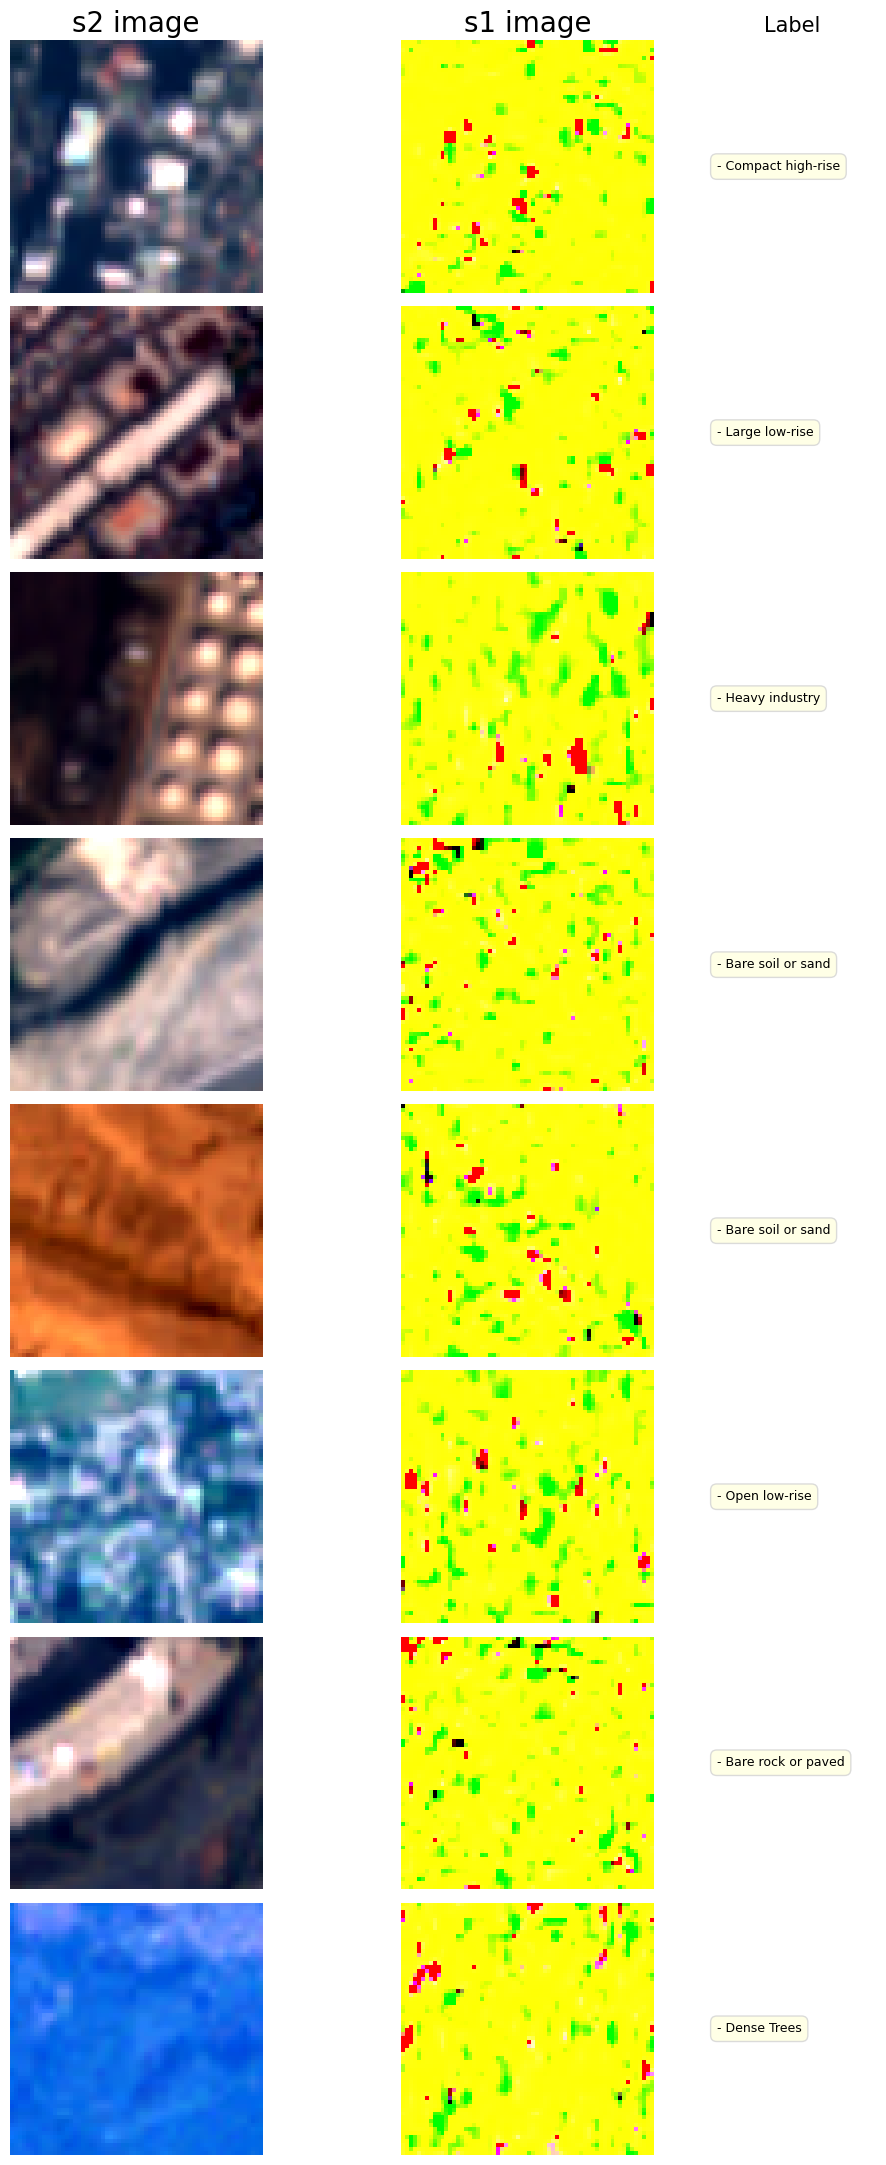

In [7]:
fig, batch = datamodule.visualize_batch()